In [18]:
# Import functions from preprocessing.py
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch
import torch.optim as optim
from tqdm import tqdm


# Add the path to the src directory
sys.path.append(os.path.abspath(os.path.join('..', 'data')))
from generation import generate_data, partition_domain_into_regions


In [19]:
# Import functions from generation.py
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from trainer_debug import trainer, compute_q_phi
from elbo import vi_piX, vi_piS


In [20]:
B = 100 # Number of regions
n_i = 4 # Number of locations per region

# Generate data
y, x, w, e, s, region_assignments = generate_data(B, n_i, sigmasq = 5, length_scale=0.5, nu=0.5, seed=50, beta_true=8, tausq_true=0.25)

# jumbled data generation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = 1
# num_neighbors= 3

y = torch.tensor(y, dtype=torch.float32, device=device)
x = torch.tensor(x, dtype=torch.float32, device=device)
w = torch.tensor(w, dtype=torch.float32, device=device)
e = torch.tensor(e, dtype=torch.float32, device=device)
s = torch.tensor(s, dtype=torch.float32, device=device)
region_assignments = torch.tensor(region_assignments, dtype=torch.int64, device=device)  # Region indices as integers
unique_regions = torch.unique(region_assignments)


# Jumble x and s within regions
x_jumbled_within_regions = torch.zeros_like(x)
s_jumbled_within_regions = torch.zeros_like(s)
torch.manual_seed(42)  # Set a seed for reproducibility
perm_x = torch.randperm(n_i)
perm_s = torch.randperm(n_i)

for i, region in enumerate(unique_regions):
    # Get indices for the current region
    indices = torch.where(region_assignments == region)[0]
    
    # Shuffle the indices within the region
    
    # Assign the shuffled values back
    x_jumbled_within_regions[indices] = x[indices[perm_x]]
    s_jumbled_within_regions[indices] = s[indices[perm_s]]

# Print the jumbled data
print("Jumbled x within regions:", x_jumbled_within_regions)
print("Jumbled s within regions:", s_jumbled_within_regions)

# Convert perm_s into a permutation matrix
perm_matrix_s = torch.zeros(n_i, n_i, dtype=torch.float32, device=device)
perm_matrix_s[torch.arange(n_i), perm_s] = 1

# Convert perm_x into a permutation matrix
perm_matrix_x = torch.zeros(n_i, n_i, dtype=torch.float32, device=device)
perm_matrix_x[torch.arange(n_i), perm_x] = 1

# Print the permutation matrices
print("Permutation matrix for perm_s:\n", perm_matrix_s)
print("Permutation matrix for perm_x:\n", perm_matrix_x)

Jumbled x within regions: tensor([[0.5868],
        [0.6929],
        [0.2578],
        [0.2964],
        [0.4909],
        [0.8243],
        [0.0580],
        [0.7636],
        [0.0960],
        [0.5975],
        [0.4066],
        [0.2932],
        [0.2888],
        [0.1660],
        [0.2093],
        [0.5915],
        [0.7576],
        [0.3488],
        [0.8965],
        [0.6729],
        [0.8119],
        [0.5183],
        [0.5019],
        [0.4756],
        [0.4176],
        [0.1541],
        [0.1428],
        [0.2570],
        [0.5549],
        [0.8586],
        [0.8590],
        [0.1698],
        [0.7584],
        [0.2106],
        [0.5405],
        [0.1429],
        [0.9411],
        [0.7474],
        [0.2136],
        [0.0709],
        [0.4823],
        [0.6472],
        [0.1892],
        [0.9531],
        [0.7960],
        [0.9423],
        [0.9398],
        [0.0597],
        [0.0675],
        [0.0975],
        [0.3128],
        [0.9863],
        [0.2000],
        [0.5234],
  

In [21]:
import torch
import torch
import torch.optim as optim
from elbo import vi_piX, vi_piS
from tqdm import tqdm

def nearest_pd_torch(A, epsilon=1e-6):
    """
    Find the nearest positive definite matrix to A using eigenvalue clipping.

    Args:
        A (torch.Tensor): A symmetric matrix (n x n).
        epsilon (float): Minimum eigenvalue threshold to ensure positive definiteness.

    Returns:
        torch.Tensor: A positive definite matrix close to A.
    """
    # Ensure symmetry
    A_sym = (A + A.T) / 2

    # Eigen decomposition
    eigvals, eigvecs = torch.linalg.eigh(A_sym)

    # Clip eigenvalues to be at least epsilon
    eigvals_clipped = torch.clamp(eigvals, min=epsilon)

    # Reconstruct matrix: V Λ V^T
    A_pd = eigvecs @ torch.diag(eigvals_clipped) @ eigvecs.T

    # Ensure symmetry again (numerical stability)
    A_pd = (A_pd + A_pd.T) / 2

    return A_pd

def compute_q_phi(phi, Dist, mu_W, Sigma_W, lambda_a1, lambda_b1, eps = 1e-6):
    """
    Compute q(phi) as defined by the given expression.

    Args:
    - phi (scalar): The tensor for which q(phi) needs to be calculated (B x d).
    - Dist (torch.Tensor): The distance matrix (nB X nB).
    - Sigma_W (torch.Tensor): The matrix Sigma_W (nB x nB).
    - mu_W (torch.Tensor): The vector mu_W (d,).
    - lambda_a1 (float): The scalar value for lambda_a1.
    - lambda_b1 (float): The scalar value for lambda_b1.
    
    Returns:
    - q_phi (torch.Tensor): The calculated q(phi).
    """
    
    # Compute R(phi)
    R_phi = torch.exp(-phi * Dist)

    # Optionally: Ensure R_phi is positive-definite
    R_phi += eps * torch.eye(R_phi.size(0), device=R_phi.device)

    # Compute log(det(R_phi)) safely
    sign, logdet = torch.linalg.slogdet(R_phi)
    if sign <= 0:
        # Handle log of non-positive determinant safely
        logdet = torch.tensor(float('-inf'), device=R_phi.device)

    # Solve R_phi x = mean
    mu_W_flat = mu_W.flatten()
    V_W = Sigma_W + torch.outer(mu_W_flat, mu_W_flat)

    R_phi_inv_mean = torch.linalg.solve(R_phi, V_W)

    # Compute exponent
    exponent = -0.5 * logdet - (lambda_a1 / (2 * lambda_b1)) * (torch.trace(R_phi_inv_mean))

    # Return log of q_phi (numerically stable)
    return exponent  # this is log(q_phi), better for log-domain work
 
    


In [22]:
    
n_iter = 100
n_blocks = B
n_locations = n_i

# Random toy data for X and Y
X = torch.tensor(x_jumbled_within_regions, dtype=torch.float32).reshape(n_blocks, n_locations)
Y = torch.tensor(y, dtype=torch.float32).reshape(n_blocks, n_locations)

# Generate (n_blocks * n_locations) 2D coordinates
total_points = n_blocks * n_locations
locations = torch.tensor(s_jumbled_within_regions,dtype=torch.float32)

# Compute distance matrix from locations
Dist= torch.cdist(locations, locations, p=2)

# Set optional args
n_steps = 50
n_phi_samples = 1000
n_piX_sample = 50
tau_X = 0.3
tau_S = 0.3
n_piS_sample = 50

fix_Sigma_W = False
fix_mu_W = False
fix_mean_Rphi_inv = False
fix_piX = True
fix_piS = True
fix_mu_lambda_beta = False
fix_sigmasq_lambda_beta = False
fix_lambda_b1 = True
fix_lambda_b2 = False
phi_init=0.5
lambda_b1_fixed = 200.1 * 5
phi_prior_ub=20
seed = 44
M_X_star_fixed = perm_matrix_x.T
V_X_star_fixed = torch.eye(n_locations, n_locations, device=device)
M_S_star_fixed = perm_matrix_s.T
V_S_star_fixed = torch.eye(n_locations, n_locations, device=device)

a1 = 0.1
b1 = 0.1
a2 = 0.1
b2 = 0.1
eta_X_sq = 0.1
eta_S_sq = 0.1
sigmasq_beta = 100
# Phi_max = torch.sqrt(2)

# Model parameters
mu_lambda_beta = 0.1
sigmasq_lambda_beta = 0.1
mu_W = torch.zeros(n_blocks, n_locations)
Sigma_W = torch.eye(n_blocks * n_locations) 
R_phi = torch.exp(-phi_init * Dist)
mean_Rphi_inv = torch.linalg.inv(nearest_pd_torch(R_phi))
# M_S_star = (1/n_locations) * torch.ones(n_locations, n_locations)
# M_X_star = (1/n_locations) * torch.ones(n_locations, n_locations)
# V_S_star = torch.eye(n_locations)
# V_X_star = torch.eye(n_locations)
lambda_a1 = n_blocks * n_locations * 0.5 + a1
lambda_b1 = 0.5
lambda_a2 = n_blocks * n_locations * 0.5 + a2
lambda_b2 = 0.5

# Initialize the model
model_piX = vi_piX(n_locations=n_locations)
model_piS = vi_piS(n_locations=n_locations)

# # Initialize parameters
M_X_star = model_piX.current_M_X_star.clone().data 
V_X_star = model_piX.current_V_X_star.clone().data
M_S_star = model_piS.current_M_S_star.clone().data
V_S_star = model_piS.current_V_S_star.clone().data


# Define the optimizer
optimizer_piX = optim.AdamW(model_piX.parameters(), lr=0.1, weight_decay=1e-2)  
optimizer_piS = optim.AdamW(model_piS.parameters(), lr=0.1, weight_decay=1e-2)


/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_55838/717390496.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(x_jumbled_within_regions, dtype=torch.float32).reshape(n_blocks, n_locations)
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_55838/717390496.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(y, dtype=torch.float32).reshape(n_blocks, n_locations)
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_55838/717390496.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor

In [34]:
# compute sigmasq_lambda_beta
X_V_X_star_X = torch.einsum('bi,ij,bj->b', X, V_X_star, X).sum()
#print("Norm of X_V_X_star_X:", torch.norm(X_V_X_star_X))
if(fix_sigmasq_lambda_beta == False):
    sigmasq_lambda_beta = 1.0 / (((lambda_a2 * X_V_X_star_X) / lambda_b2) + (1.0 / sigmasq_beta))
else: 
    sigmasq_lambda_beta = sigmasq_lambda_beta_fixed

# compute mu_lambda_beta
residual = Y - (M_S_star @ mu_W.T).T
X_M_X_star_residual = torch.einsum('bi,ij,bj->b', X, M_X_star.T, residual).sum()
#print("Norm of X_M_X_star_residual:", torch.norm(X_M_X_star_residual))
if(fix_mu_lambda_beta == False):
    mu_lambda_beta = sigmasq_lambda_beta * (lambda_a2 / lambda_b2) * X_M_X_star_residual
else:
    mu_lambda_beta = mu_lambda_beta_fixed

# lambda_b1
if(fix_lambda_b1 == False):
    lambda_b1 = 0.5 * (torch.trace(mean_Rphi_inv @ Sigma_W) + mu_W.flatten().T @ mean_Rphi_inv @ mu_W.flatten()) + b1
else:
    lambda_b1 = lambda_b1_fixed

res = Y - mu_lambda_beta * (M_X_star @ X.T).T - (M_S_star @ mu_W.T).T
term = torch.trace(res.T @ res)  # (1, 1)
term += mu_lambda_beta ** 2 * torch.trace(X @ (V_X_star - M_X_star.T @ M_X_star) @ X.T)
min_eigen_value = torch.min(torch.linalg.eigvalsh(V_X_star - M_X_star.T @ M_X_star))
print(f"Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: {min_eigen_value:.4e}")
term += sigmasq_lambda_beta * torch.trace(X @ V_X_star @ X.T)
term += torch.trace(mu_W @ (V_S_star - M_S_star.T @ M_S_star) @ mu_W.T)
term += torch.trace(torch.block_diag(*[V_S_star] * n_blocks) @ Sigma_W)          
if(fix_lambda_b2 == False):
    lambda_b2 = 0.5 * term + b2
else:
    lambda_b2 = lambda_b2_fixed
        
    
# compute Sigma_W
term1 = (lambda_a2 / lambda_b2) * torch.block_diag(*[V_S_star] * n_blocks)
term2 = (lambda_a1 / lambda_b1) * mean_Rphi_inv
# Sum the terms and take the inverse
if(fix_Sigma_W == False):
    Sigma_W = torch.linalg.pinv(term1 + term2, rtol = 1e-3)
else:
    Sigma_W = Sigma_W_fixed

# compute mu_W        
#print("Norm of residual2:", torch.norm((M_S_star.T @ Y.T - mu_lambda_beta * M_S_star.T @ M_X_star @ X.T).T.flatten()))

if(fix_mu_W == False):
    mu_W = (lambda_a2 / lambda_b2) * (Sigma_W @ (M_S_star.T @ Y.T - mu_lambda_beta * M_S_star.T @ M_X_star @ X.T).T.flatten()).reshape(n_blocks, n_locations)
else:
    mu_W = mu_W_fixed


phi_samples = torch.rand(n_phi_samples) * (phi_prior_ub - (1 / torch.max(Dist))) + (1 / torch.max(Dist))
# Calculate q_phi for each phi_sample
q_phi_values = torch.tensor([compute_q_phi(phi, Dist, mu_W, Sigma_W, lambda_a1, lambda_b1) for phi in phi_samples])

# Normalize the importance weights
importance_weights = torch.nn.functional.softmax(q_phi_values, dim=0)

Rphi_inv_sum = torch.zeros_like(Dist)
R_sum = 0
for i in range(n_phi_samples):
    # Compute the weighted sum of phi_samples
    Rphi_inv = torch.linalg.pinv(torch.exp(-phi_samples[i] * Dist), rtol=1e-3)
    Rphi_inv_sum += importance_weights[i] * Rphi_inv
    R_sum += importance_weights[i] * phi_samples[i]

mean_Rphi_inv = Rphi_inv_sum   
# Compute the mean of R(phi)^-1
# make this stable
if(fix_mean_Rphi_inv == False):
    mean_Rphi_inv = nearest_pd_torch(mean_Rphi_inv)
else:
    mean_Rphi_inv = mean_Rphi_inv_fixed    
#print("mean_Rphi_inv:", mean_Rphi_inv)


if(fix_piX== False):
    # Minimize the model for piX
    for step in range(n_steps):
        optimizer_piX.zero_grad()  # Clear gradients
        loss = model_piX(Y, X, mu_lambda_beta, sigmasq_lambda_beta, M_S_star, mu_W, eta_X_sq, lambda_a2, lambda_b2, tau_X, n_piX_sample,seed=seed)
        #torch.autograd.set_detect_anomaly(True)  # Enable anomaly detection
        loss.backward()  # Compute gradients
        optimizer_piX.step()  # Update parameters

        # # Print loss every 100 steps
        # if step % 1 == 0:
        #     print(f"Step {step}, Loss: {loss.item()}")
        #     print("Current MX:")
        #     print(torch.exp(model_piX.MX.data))

        #     print("\nCurrent VX:")
        #     print(torch.exp(model_piX.VX.data))
            
        #     # Stopping rule: Stop if the loss change is below a threshold
        #     if step > 0 and abs(prev_loss - loss.item()) < 1e-4:
        #         print(f"Stopping early at step {step} due to minimal loss change.")
        #         break
        #     prev_loss = loss.item()
    
    #print("Pix_loss", loss.item())

    # Extract the updated parameters

    M_X_star = model_piX.current_M_X_star.clone().data 
    V_X_star = model_piX.current_V_X_star.clone().data
else:
    M_X_star = M_X_star_fixed
    V_X_star = V_X_star_fixed


if(fix_piS == False):
    # Minimize the model for piS
    for step in range(n_steps):
        optimizer_piS.zero_grad()  # Clear gradients
        loss = model_piS(Y, X, mu_lambda_beta, M_X_star, lambda_a2, lambda_b2,
                        mu_W, Sigma_W, eta_S_sq, tau_S, n_piS_sample, seed=seed)
        loss.backward()  # Compute gradients
        optimizer_piS.step()  # Update parameters

        # # Print loss every step (or change 1 to 100 if you want sparser output)
        # if step % 1 == 0:
        #     print(f"Step {step}, Loss: {loss.item()}")
        #     print("Current MS:")
        #     print(torch.exp(model_piS.MS.data))

        #     print("\nCurrent VS:")
        #     print(torch.exp(model_piS.VS.data))

        #     # Stopping rule: Stop if the loss change is below a threshold
        #     if step > 0 and abs(prev_loss - loss.item()) < 1e-4:
        #         print(f"Stopping early at step {step} due to minimal loss change.")
        #         break
        #     prev_loss = loss.item()
        
    #print("PiS_loss", loss.item())


# Extract the updated parameters

    M_S_star = model_piS.current_M_S_star.clone().data
    V_S_star = model_piS.current_V_S_star.clone().data
else:
    M_S_star = M_S_star_fixed
    V_S_star = V_S_star_fixed

print("phi_mean", R_sum)

Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 0.0000e+00
phi_mean tensor(5.7729)


In [35]:
torch.manual_seed(43)
phi_samples = torch.rand(100) * (20- (1 / torch.max(Dist))) + (1 / torch.max(Dist))
# Calculate q_phi for each phi_sample
q_phi_values = torch.tensor([compute_q_phi(phi, Dist, mu_W, Sigma_W, lambda_a1, lambda_b1) for phi in phi_samples])

# Normalize the importance weights
importance_weights = torch.nn.functional.softmax(q_phi_values, dim=0)

Rphi_inv_sum = torch.zeros_like(Dist)
R_sum = 0
for i in range(n_phi_samples):
    # Compute the weighted sum of phi_samples
    Rphi_inv = torch.linalg.pinv(torch.exp(-phi_samples[i] * Dist), rtol=1e-3)
    Rphi_inv_sum += importance_weights[i] * Rphi_inv
    R_sum += importance_weights[i] * phi_samples[i]

mean_Rphi_inv = Rphi_inv_sum
mean_phi = R_sum
# Compute the mean of R(phi)^-1
# make this stable
if(fix_mean_Rphi_inv == False):
    mean_Rphi_inv = nearest_pd_torch(mean_Rphi_inv)
else:
    mean_Rphi_inv = mean_Rphi_inv_fixed  

print("mean_phi:", mean_phi)

IndexError: index 100 is out of bounds for dimension 0 with size 100

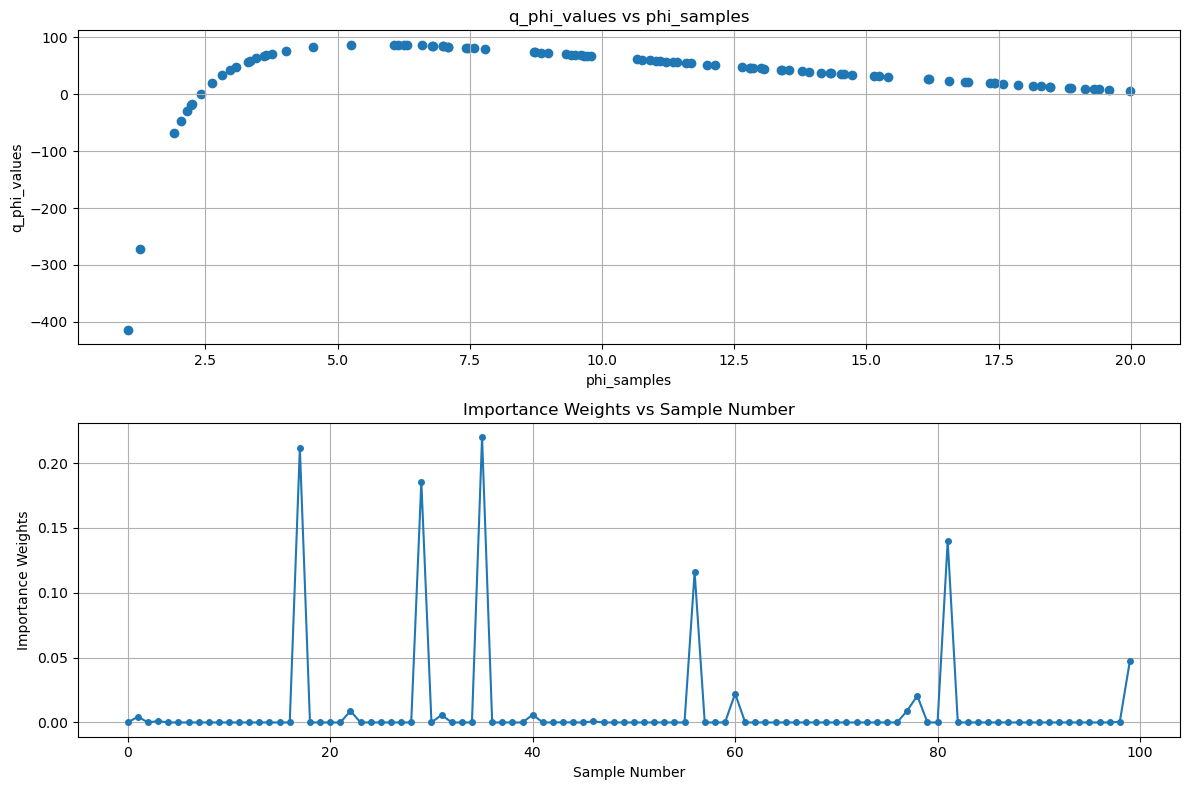

In [36]:
plt.figure(figsize=(12, 8))

# Subplot 1: q_phi_values vs phi_samples
plt.subplot(2, 1, 1)
plt.scatter(phi_samples.cpu().numpy(), q_phi_values.cpu().numpy(), marker='o')
plt.xlabel('phi_samples')
plt.ylabel('q_phi_values')
plt.title('q_phi_values vs phi_samples')
plt.grid(True)

# Subplot 2: importance weights vs sample number
plt.subplot(2, 1, 2)
plt.plot(range(len(importance_weights)), importance_weights.cpu().numpy(), marker='o', linestyle='-', markersize=4)
plt.xlabel('Sample Number')
plt.ylabel('Importance Weights')
plt.title('Importance Weights vs Sample Number')
plt.grid(True)

plt.tight_layout()
plt.show()



In [27]:
# Find indices where vvv > 0.2
vvv = torch.nn.functional.softmax(q_phi_values, dim=0)
indices = torch.where(vvv > 0.2)

# Print the indices
print("Indices where vvv > 0.2:", indices)

# Find the corresponding phi_samples
corresponding_phi_samples = phi_samples[indices[0]]
print("Corresponding phi_samples:", corresponding_phi_samples)

Indices where vvv > 0.2: (tensor([17]),)
Corresponding phi_samples: tensor([0.7992])


In [ ]:
phi_samples = torch.rand(n_phi_samples) * (phi_prior_ub - (1 / torch.max(Dist))) + (1 / torch.max(Dist))
# Calculate q_phi for each phi_sample
q_phi_values = torch.tensor([compute_q_phi(phi, Dist, mu_W, Sigma_W, lambda_a1, lambda_b1) for phi in phi_samples])

# Normalize the importance weights
importance_weights = torch.nn.functional.softmax(q_phi_values, dim=0)

Rphi_inv_sum = torch.zeros_like(Dist)
for i in range(n_phi_samples):
    # Compute the weighted sum of phi_samples
    Rphi_inv = torch.linalg.pinv(torch.exp(-phi_samples[i] * Dist), rtol=1e-3)
    Rphi_inv_sum += importance_weights[i] * Rphi_inv

mean_Rphi_inv = Rphi_inv_sum
# Compute the mean of R(phi)^-1
# make this stable
if(fix_mean_Rphi_inv == False):
    mean_Rphi_inv = nearest_pd_torch(mean_Rphi_inv)
else:
    mean_Rphi_inv = mean_Rphi_inv_fixed  

In [44]:
def exponential_kernel(X1, X2, length_scale=1.0, sigma=1.0):
    """
    Computes the Matérn covariance function with ν = 1/2 (exponential covariance).

    Args:
        X1 (torch.Tensor): Input tensor of shape (n, d).
        X2 (torch.Tensor): Input tensor of shape (m, d).
        rho (float): Characteristic lengthscale parameter.
        sigma (float): Scaling factor (variance term).

    Returns:
        torch.Tensor: Covariance matrix of shape (n, m).
    """
    dists = torch.cdist(X1, X2, p=2)  # Compute pairwise Euclidean distances
    return sigma * torch.exp(-dists / length_scale)

unique_regions = torch.unique(region_assignments)
B = len(unique_regions)

# Compute full covariance matrix for all locations using Matern kernel
#scaled_s = s / length_scale
matern_kernel = exponential_kernel(s, s, length_scale=0.5)
K = 5 * matern_kernel  # Scale by variance

# Initialize variance-covariance matrix
cov_matrix = torch.zeros((B, B))

# Create a binary indicator matrix of shape (num_samples, num_regions)
region_mask = torch.stack([(region_assignments == region).float() for region in unique_regions], dim=1)

# Compute region sizes (n_i for each region)
region_sizes = region_mask.sum(dim=0, keepdim=True)  # Shape: (1, num_regions)

# Compute the covariance matrix efficiently
# Equivalent to looping over i, j but using matrix multiplication
region_sums = region_mask.T @ K @ region_mask  # Shape: (num_regions, num_regions)
cov_matrix = region_sums / (region_sizes.T @ region_sizes)  # Element-wise division

# Ensure numerical stability by avoiding division by zero
cov_matrix[region_sizes.T @ region_sizes == 0] = 0

# Add diagonal tausq / n_i term
diag_tau_term = torch.diag(0.25 / region_sizes)* torch.eye(B)  # Shape: (num_regions, num_regions)
cov_matrix += diag_tau_term